### Lasso Regression

- `Main concept:  `   Use to reduce overfitting as well as eliminate use less features.
- `Working:  `     Add a penalizing term in Cost function

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Data\\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
from sklearn.model_selection import train_test_split
X = df.drop(['charges','region'],axis = 1)
y = df.charges
X['sex'] = X['sex'].map({'male': 1,"female" :0})
X['smoker'] = X['smoker'].map({'yes': 1, "no": 0})
X['bmi_smoker'] = X['bmi']*X['smoker']
X['age_smoker'] = X['age']*X['smoker']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

lasso = Lasso(alpha=0.5)
lasso.fit(X_train,y_train)

test_pred = lasso.predict(X_test)
mse = mean_squared_error(y_test, test_pred)
print("MSE: " , mse)

MSE:  21246786.558020215


In [8]:
alphas = [0.01,0.1,1,10,100]
mses = []

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train,y_train)

    test_pred = lasso.predict(X_test)
    mse = mean_squared_error(y_test, test_pred)
    print(f"MSE for alpha {a}: {mse}")
    mses.append(mse)

MSE for alpha 0.01: 21251205.36578633
MSE for alpha 0.1: 21250385.23453921
MSE for alpha 1: 21242384.75073261
MSE for alpha 10: 21183281.43048729
MSE for alpha 100: 22439370.42589527


<Axes: >

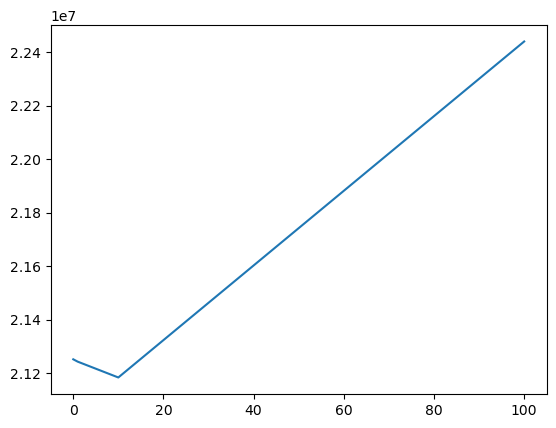

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x = alphas, y= mses)
